In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

**Loading Dataset**

In [ ]:
df = pd.read_csv("HR-Employee-Attrition.csv")
print(df.head())
print(df.info())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

**Dataset Overview**

In [ ]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"\nTotal Employees   : {df.shape[0]}")
print(f"Total Features    : {df.shape[1]}")
print(f"Missing Values    : {df.isnull().sum().sum()}")
print(f"\nAttrition Counts:\n{df['Attrition'].value_counts()}")
print(f"\nAttrition Rate    : {round(df['Attrition'].value_counts(normalize=True)['Yes']*100, 2)}%")

DATASET OVERVIEW

Total Employees   : 1470
Total Features    : 35
Missing Values    : 0

Attrition Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate    : 16.12%


**Attrition Distribution**

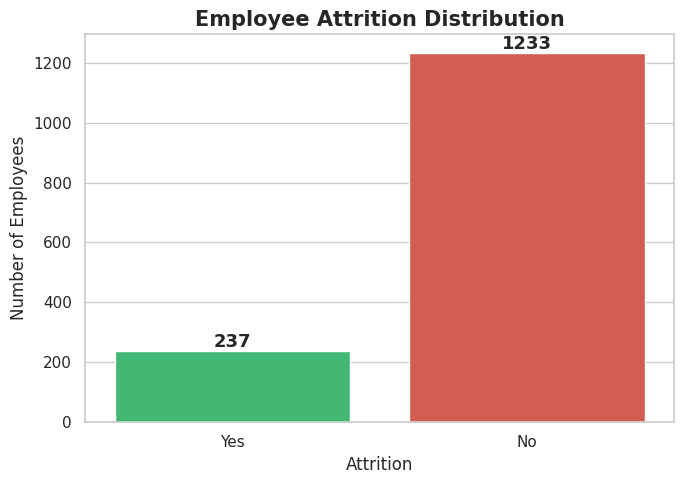

In [ ]:
plt.figure(figsize=(7, 5))
colors = ['#2ecc71', '#e74c3c']
ax = sns.countplot(x='Attrition', data=df, palette=colors)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.title('Employee Attrition Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Attrition', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.tight_layout()
plt.savefig('plot1_attrition_count.png', dpi=150)
plt.show()

**Attrition by Department**

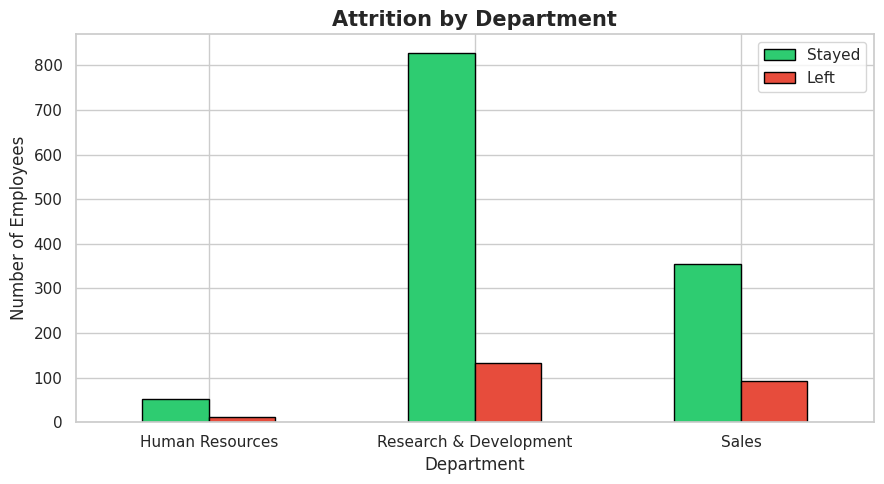

In [ ]:
dept_attrition = df.groupby(['Department', 'Attrition']).size().unstack()
dept_attrition.plot(kind='bar', color=['#2ecc71', '#e74c3c'],
                    figsize=(9, 5), edgecolor='black')

plt.title('Attrition by Department', fontsize=15, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Stayed', 'Left'], fontsize=11)
plt.tight_layout()
plt.savefig('plot2_attrition_by_department.png', dpi=150)
plt.show()

**Attrition by Age Group**

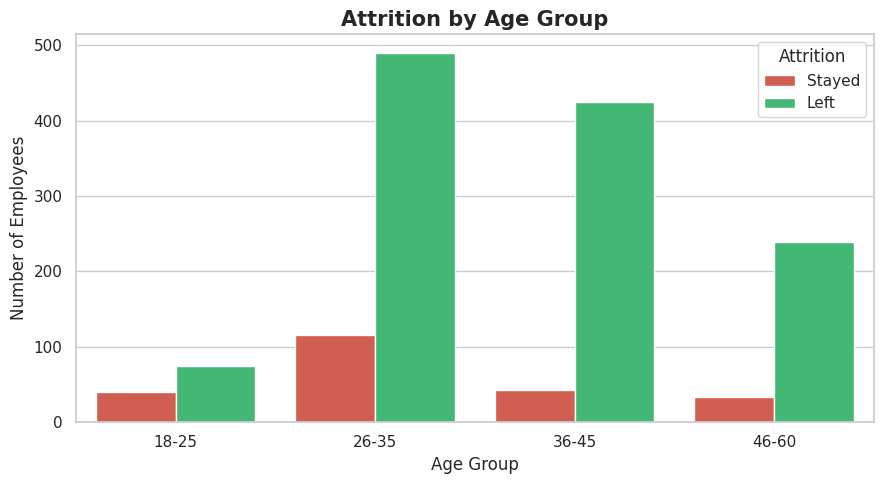

In [ ]:
df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[18, 25, 35, 45, 60],
                         labels=['18-25', '26-35', '36-45', '46-60'])

plt.figure(figsize=(9, 5))
sns.countplot(x='AgeGroup', hue='Attrition', data=df,
              palette={'No': '#2ecc71', 'Yes': '#e74c3c'})

plt.title('Attrition by Age Group', fontsize=15, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.legend(title='Attrition', labels=['Stayed', 'Left'])
plt.tight_layout()
plt.savefig('plot3_attrition_by_age.png', dpi=150)
plt.show()

**Monthly Income vs Attrition**

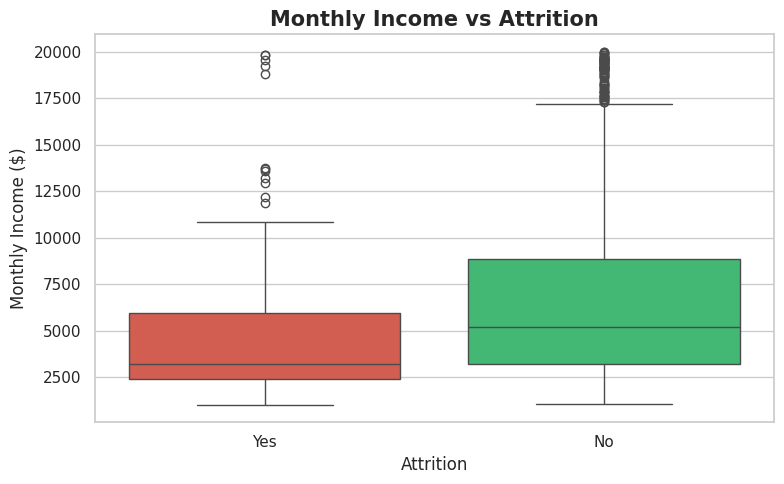

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df,
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})

plt.title('Monthly Income vs Attrition', fontsize=15, fontweight='bold')
plt.xlabel('Attrition', fontsize=12)
plt.ylabel('Monthly Income ($)', fontsize=12)
plt.tight_layout()
plt.savefig('plot4_income_vs_attrition.png', dpi=150)
plt.show()

**Overtime vs Attrition**

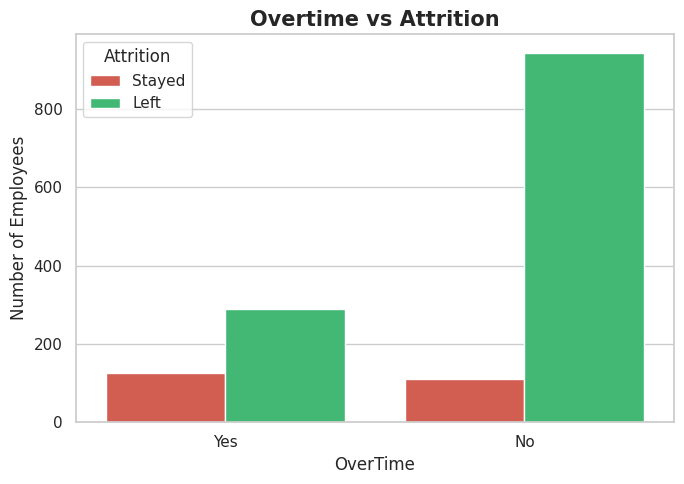

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(x='OverTime', hue='Attrition', data=df,
              palette={'No': '#2ecc71', 'Yes': '#e74c3c'})

plt.title('Overtime vs Attrition', fontsize=15, fontweight='bold')
plt.xlabel('OverTime', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.legend(title='Attrition', labels=['Stayed', 'Left'])
plt.tight_layout()
plt.savefig('plot5_overtime_vs_attrition.png', dpi=150)
plt.show()

**Job Satisfaction vs Attrition**

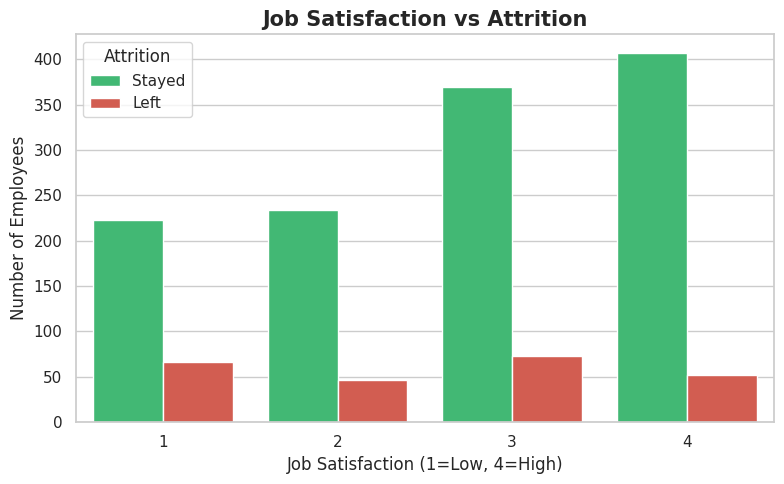

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df,
              palette={'No': '#2ecc71', 'Yes': '#e74c3c'})

plt.title('Job Satisfaction vs Attrition', fontsize=15, fontweight='bold')
plt.xlabel('Job Satisfaction (1=Low, 4=High)', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.legend(title='Attrition', labels=['Stayed', 'Left'])
plt.tight_layout()
plt.savefig('plot6_jobsatisfaction_vs_attrition.png', dpi=150)
plt.show()

**Correlation Heatmap**

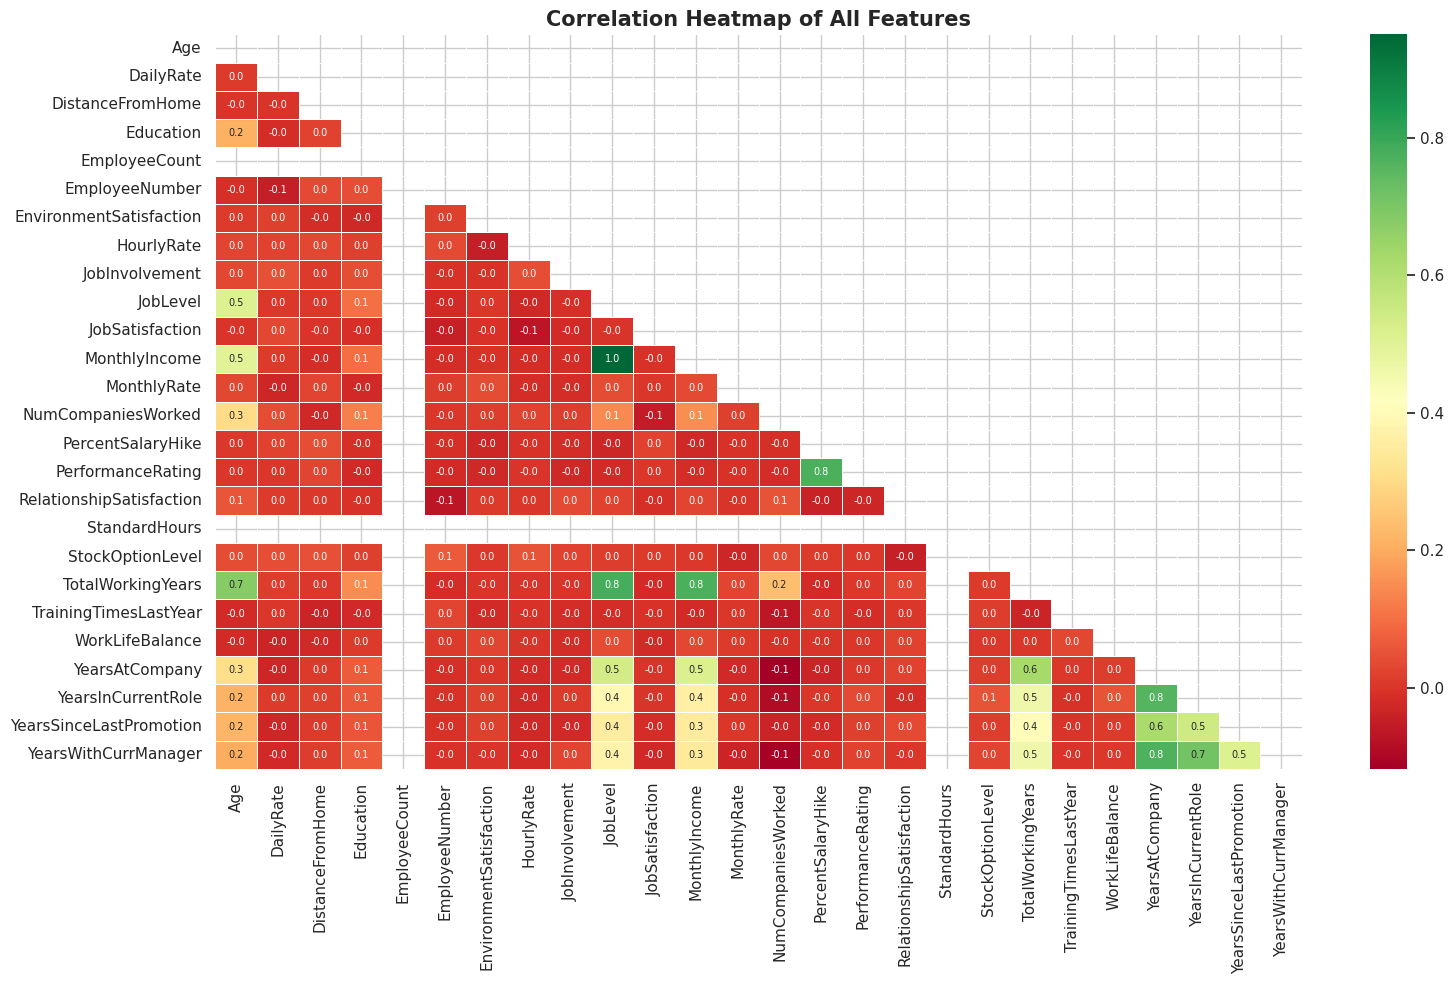

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(16, 10))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.1f',
            cmap='RdYlGn', linewidths=0.5,
            annot_kws={"size": 7})

plt.title('Correlation Heatmap of All Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot7_correlation_heatmap.png', dpi=150)
plt.show()

**Key Insights Summary**

In [ ]:
print("=" * 55)
print("         KEY INSIGHTS FROM EDA")
print("=" * 55)

attrition_rate = round(df['Attrition'].value_counts(normalize=True)['Yes'] * 100, 2)
print(f"\n1. Overall Attrition Rate     : {attrition_rate}%")

dept_rate = df.groupby('Department')['Attrition'].apply(
    lambda x: round((x == 'Yes').sum() / len(x) * 100, 2))
print(f"\n2. Attrition Rate by Department:\n{dept_rate.to_string()}")

ot_yes = df[df['OverTime'] == 'Yes']['Attrition'].value_counts(normalize=True)['Yes'] * 100
ot_no  = df[df['OverTime'] == 'No']['Attrition'].value_counts(normalize=True)['Yes'] * 100
print(f"\n3. Attrition with OverTime    : {round(ot_yes, 2)}%")
print(f"   Attrition without OverTime : {round(ot_no, 2)}%")

avg_income_left   = round(df[df['Attrition'] == 'Yes']['MonthlyIncome'].mean(), 2)
avg_income_stayed = round(df[df['Attrition'] == 'No']['MonthlyIncome'].mean(), 2)
print(f"\n4. Avg Income (Left)          : ${avg_income_left}")
print(f"   Avg Income (Stayed)        : ${avg_income_stayed}")
print("=" * 55)


         KEY INSIGHTS FROM EDA

1. Overall Attrition Rate     : 16.12%

2. Attrition Rate by Department:
Department
Human Resources           19.05
Research & Development    13.84
Sales                     20.63

3. Attrition with OverTime    : 30.53%
   Attrition without OverTime : 10.44%

4. Avg Income (Left)          : $4787.09
   Avg Income (Stayed)        : $6832.74


**Installing SHAP**

In [ ]:
!pip install shap -q

**Importing ML Libraries**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils import resample
import shap

print("✅ All ML libraries imported!")

✅ All ML libraries imported!


**Data Preprocessing**

In [ ]:
df_ml = df.copy()

# Drop columns that add no value
df_ml.drop(['EmployeeCount', 'EmployeeNumber', 'Over18',
            'StandardHours', 'AgeGroup'], axis=1, inplace=True)

# Encode target variable
df_ml['Attrition'] = df_ml['Attrition'].map({'Yes': 1, 'No': 0})

# Encode all categorical columns
le = LabelEncoder()
cat_cols = df_ml.select_dtypes(include='object').columns
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

print("✅ Preprocessing done!")
print(f"Final Shape: {df_ml.shape}")
print(f"\nAttrition Distribution:\n{df_ml['Attrition'].value_counts()}")

✅ Preprocessing done!
Final Shape: (1470, 31)

Attrition Distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64


**Handling Class Imbalance (Oversampling)**

In [ ]:
df_majority = df_ml[df_ml['Attrition'] == 0]
df_minority = df_ml[df_ml['Attrition'] == 1]

df_minority_upsampled = resample(df_minority,
                                  replace=True,
                                  n_samples=len(df_majority),
                                  random_state=42)

df_balanced = pd.concat([df_majority, df_minority_upsampled])

print("✅ Class imbalance handled!")
print(f"Balanced Attrition Distribution:\n{df_balanced['Attrition'].value_counts()}")

✅ Class imbalance handled!
Balanced Attrition Distribution:
Attrition
0    1233
1    1233
Name: count, dtype: int64


**Train-Test Split**

In [ ]:
X = df_balanced.drop('Attrition', axis=1)
y = df_balanced['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("✅ Data split done!")
print(f"Training Size : {X_train.shape[0]} rows")
print(f"Testing Size  : {X_test.shape[0]} rows")

✅ Data split done!
Training Size : 1972 rows
Testing Size  : 494 rows


**Logistic Regression Model**

In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"Accuracy : {round(lr_acc * 100, 2)}%")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Stayed', 'Left']))

LOGISTIC REGRESSION RESULTS
Accuracy : 69.23%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.70      0.67      0.69       248
        Left       0.68      0.72      0.70       246

    accuracy                           0.69       494
   macro avg       0.69      0.69      0.69       494
weighted avg       0.69      0.69      0.69       494



**Decision Tree Model**

In [ ]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
print("=" * 50)
print("DECISION TREE RESULTS")
print("=" * 50)
print(f"Accuracy : {round(dt_acc * 100, 2)}%")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=['Stayed', 'Left']))

DECISION TREE RESULTS
Accuracy : 81.58%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.79      0.86      0.82       248
        Left       0.84      0.77      0.81       246

    accuracy                           0.82       494
   macro avg       0.82      0.82      0.82       494
weighted avg       0.82      0.82      0.82       494



**Model Comparison**

In [ ]:
print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"Logistic Regression Accuracy : {round(lr_acc * 100, 2)}%")
print(f"Decision Tree Accuracy       : {round(dt_acc * 100, 2)}%")

best = "Logistic Regression" if lr_acc > dt_acc else "Decision Tree"
print(f"\n🏆 Best Model : {best}")

MODEL COMPARISON
Logistic Regression Accuracy : 69.23%
Decision Tree Accuracy       : 81.58%

🏆 Best Model : Decision Tree


**Confusion Matrix - Logistic Regression**

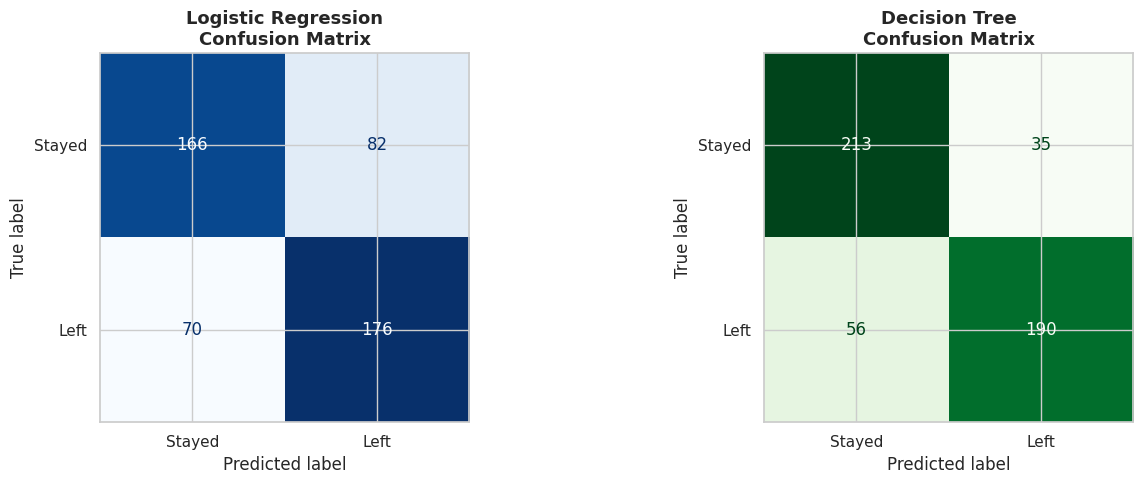

✅ Confusion Matrix saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, lr_pred)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                                  display_labels=['Stayed', 'Left'])
disp_lr.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression\nConfusion Matrix',
                   fontsize=13, fontweight='bold')

cm_dt = confusion_matrix(y_test, dt_pred)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                                  display_labels=['Stayed', 'Left'])
disp_dt.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Decision Tree\nConfusion Matrix',
                   fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('plot8_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion Matrix saved!")

**Feature Importance - Decision Tree**

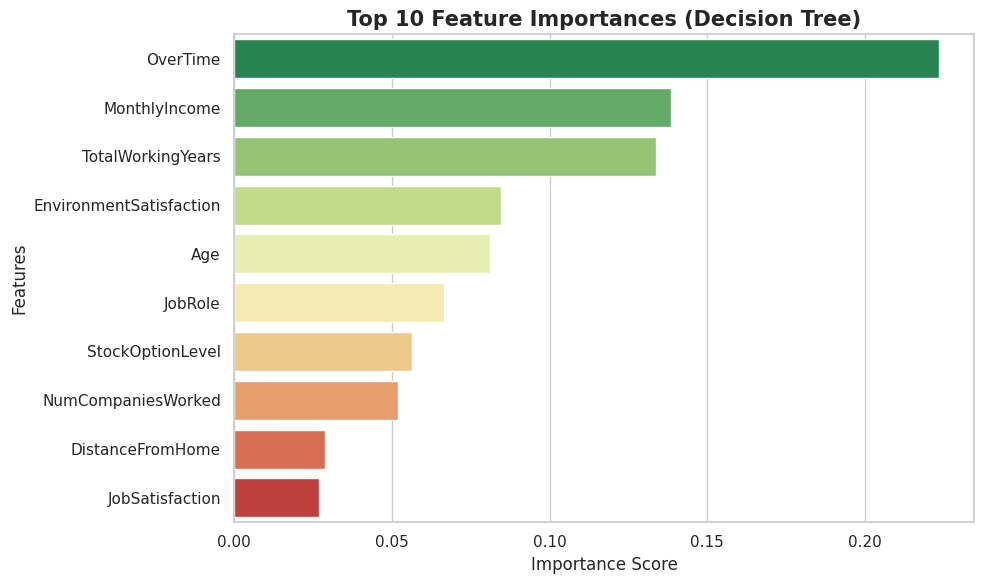

✅ Feature Importance plot saved!


In [ ]:
feature_importance = pd.Series(dt_model.feature_importances_,
                                index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance[:10].values,
            y=feature_importance[:10].index,
            palette='RdYlGn_r')

plt.title('Top 10 Feature Importances (Decision Tree)',
          fontsize=15, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig('plot9_feature_importance.png', dpi=150)
plt.show()
print("✅ Feature Importance plot saved!")

**SHAP Analysis**

Fixed SHAP values shape: (494, 30)


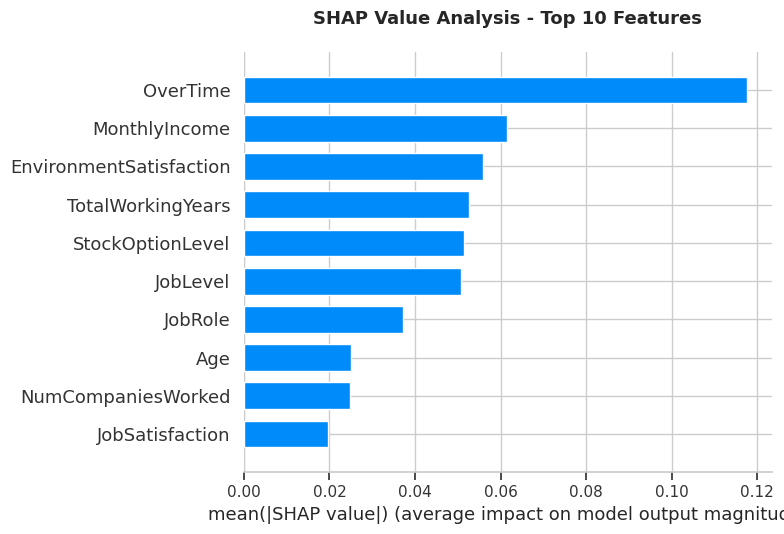

✅ SHAP Analysis saved!


In [ ]:
explainer = shap.TreeExplainer(dt_model)
shap_values = explainer.shap_values(X_test)

# shap_values shape is (494, 30, 2) — extract class 1 correctly
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv = shap_values[:, :, 1]  # shape becomes (494, 30)
elif isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print("Fixed SHAP values shape:", sv.shape)  # Should be (494, 30)

# summary_plot doesn't accept 'ax' in older shap versions — use plt directly
plt.figure(figsize=(10, 7))

shap.summary_plot(
    sv,
    X_test,
    plot_type="bar",
    max_display=10,
    show=False
)

plt.title('SHAP Value Analysis - Top 10 Features',
          fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('plot10_shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP Analysis saved!")

**Final Model Summary**

In [ ]:
print("=" * 55)
print("         FINAL MODEL SUMMARY")
print("=" * 55)
print(f"\nLogistic Regression Accuracy : {round(lr_acc * 100, 2)}%")
print(f"Decision Tree Accuracy       : {round(dt_acc * 100, 2)}%")
print(f"\n🏆 Best Model                : {best}")
print(f"\nTop 3 Attrition Factors:")
for i, feat in enumerate(feature_importance[:3].index, 1):
    print(f"  {i}. {feat}")
print("\n✅ ML Model Phase Complete!")
print("=" * 55)


         FINAL MODEL SUMMARY

Logistic Regression Accuracy : 69.23%
Decision Tree Accuracy       : 81.58%

🏆 Best Model                : Decision Tree

Top 3 Attrition Factors:
  1. OverTime
  2. MonthlyIncome
  3. TotalWorkingYears

✅ ML Model Phase Complete!
